## Extended Data Figure 1

Enviorment: env 1

In [ ]:
import pandas as pd
import pickle
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import re
import textwrap
import seaborn as sns

import sys
sys.path.append("/gpfs/data/shenhavlab/users/ca3261/Visionary-AI-HDP/code/utils/")
from utils import get_test_roc, get_test_pr, wrap_labels, bl_clean

In [2]:
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
plt.rcParams["font.family"] = "DejaVu Sans"

dpi = 300
font_size = 12
fig_size = 5

### load data

In [3]:
# for the meta pkls
# 0: prediction
# 1: probs
# 2: f1
# 3: feature sets
# 4: ground truth labels
# 5: model params

In [4]:
pec_5_path = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc/run_20251017/meta_probs_auc_0.5/XGBoost/{n_estimators_100,max_depth_3,learning_rate_0.3,subsample_1.0,scale_pos_weight_8,n_feats_8}_oof.pkl"

In [5]:
cu_all_probs = []
with open(pec_5_path, "rb") as f:
    data = pickle.load(f)
cu_all_probs.append(data[1])
cu_all_probs = pd.DataFrame(cu_all_probs)

In [6]:
clinical = pd.read_csv("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/clinical_ml_feats_20260430.csv")

In [7]:
fmf_loo = pd.read_csv("/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/data/fmf_pe_results_cu.csv")

In [8]:
fmf_loo["fmf_prob"] = fmf_loo["pe_before_delivery_percent"] / 100
fmf_loo["id"] = [id.lower() for id in fmf_loo["patient_id"]]
fmf_loo = fmf_loo[["fmf_prob", "id"]]

In [9]:
cu_all_probs = cu_all_probs.T
cu_all_probs["id"] = cu_all_probs.index
cu_all_probs = cu_all_probs.reset_index(drop=True)
cu_all_probs = cu_all_probs.merge(clinical, how="left")
cu_all_probs = cu_all_probs.merge(fmf_loo, how="left")

In [10]:
len(list(set(list(cu_all_probs["id"]))))

136

In [11]:
len(cu_all_probs[~cu_all_probs[0].isna()])

136

In [12]:
with open("/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data/final_pec_20251017.pkl", "rb") as f:
    all_pec = pickle.load(f)

In [13]:
cu_all_probs["label"] = [int(id in all_pec) for id in cu_all_probs["id"]]

In [14]:
rename_dict = {}

for i in range(10):
    rename_dict[i] = f"pw_{i + 1}"

cu_all_probs = cu_all_probs.rename(columns=rename_dict)

### Extended Data Figure 1A

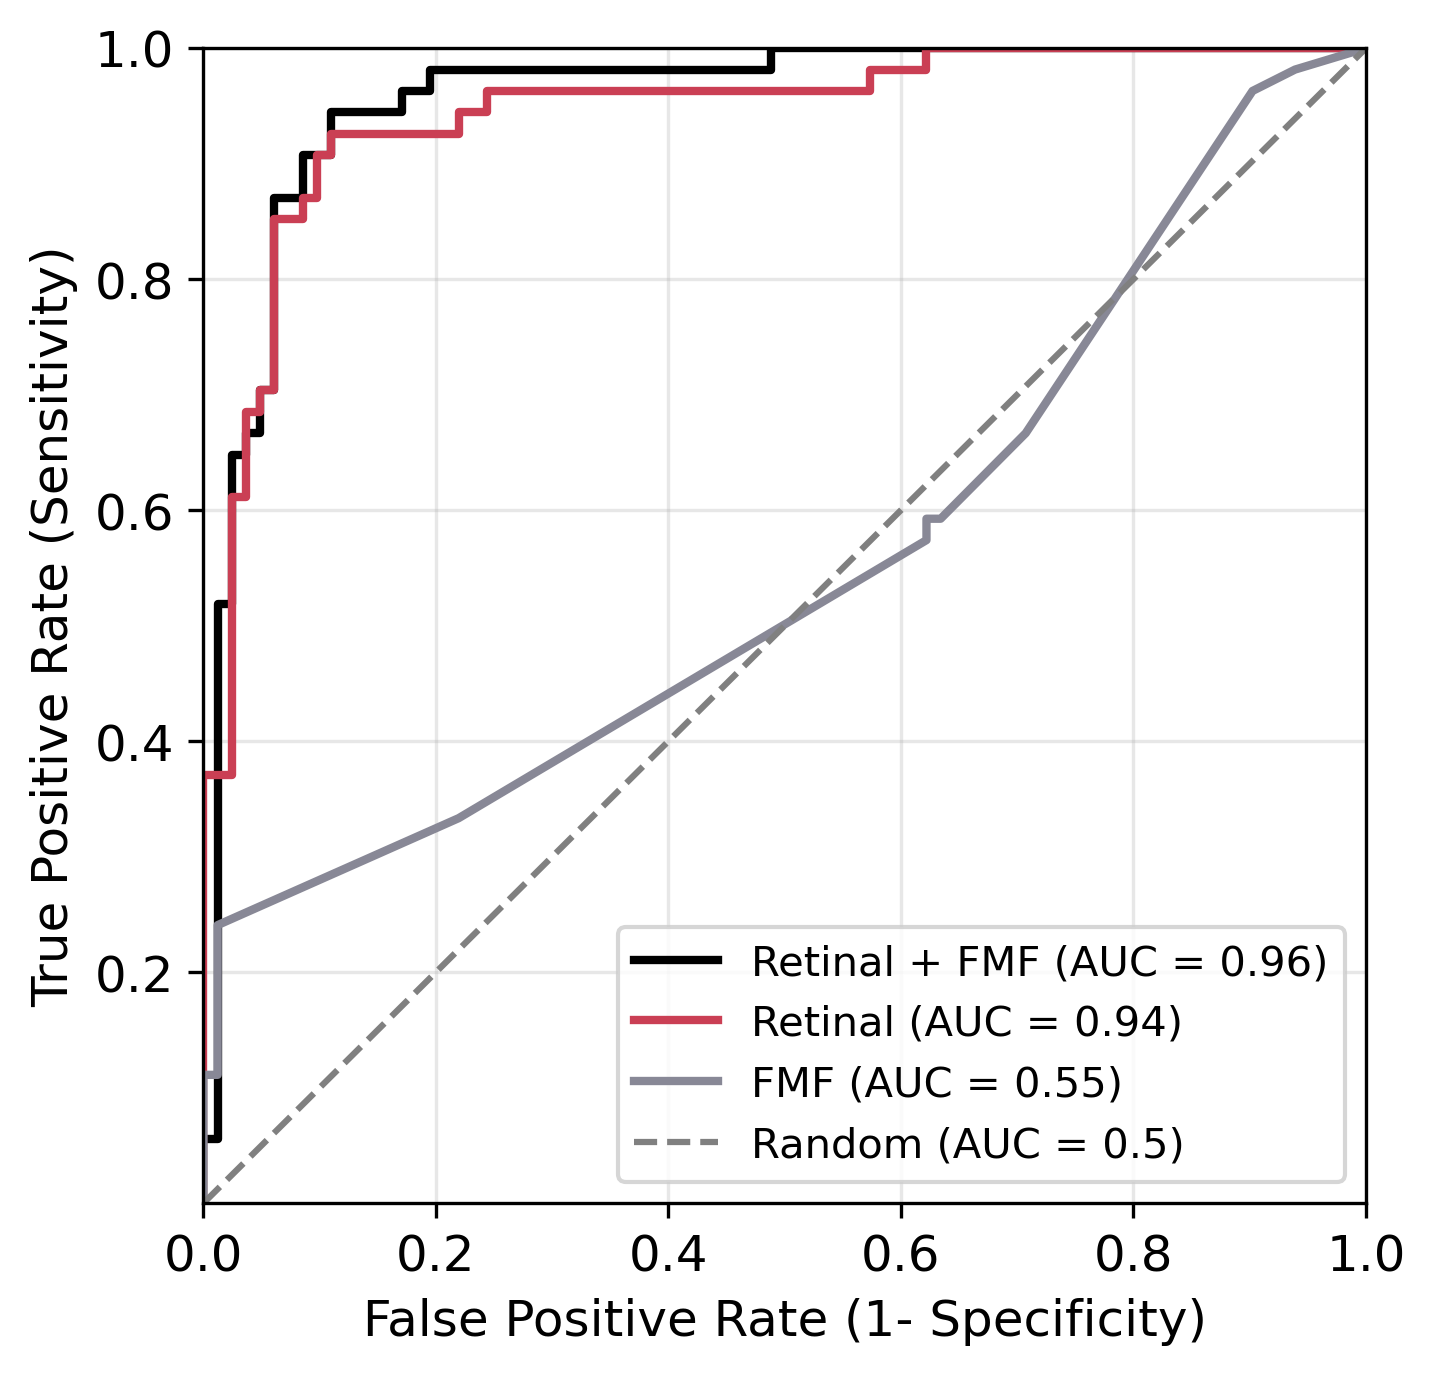

In [15]:
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)

# both
get_test_roc(cu_all_probs["label"], cu_all_probs["pw_1"] + cu_all_probs["fmf_prob"], curve_label="Retinal + FMF", color="black");

# retinal
get_test_roc(cu_all_probs["label"], cu_all_probs["pw_1"], curve_label="Retinal", color="#CA3F54")

#fmf
get_test_roc(cu_all_probs["label"], cu_all_probs["fmf_prob"], curve_label="FMF", color="#888896", rand=True)

plt.savefig('/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/extended_data/fig_1/a_roc.pdf') 

plt.show()

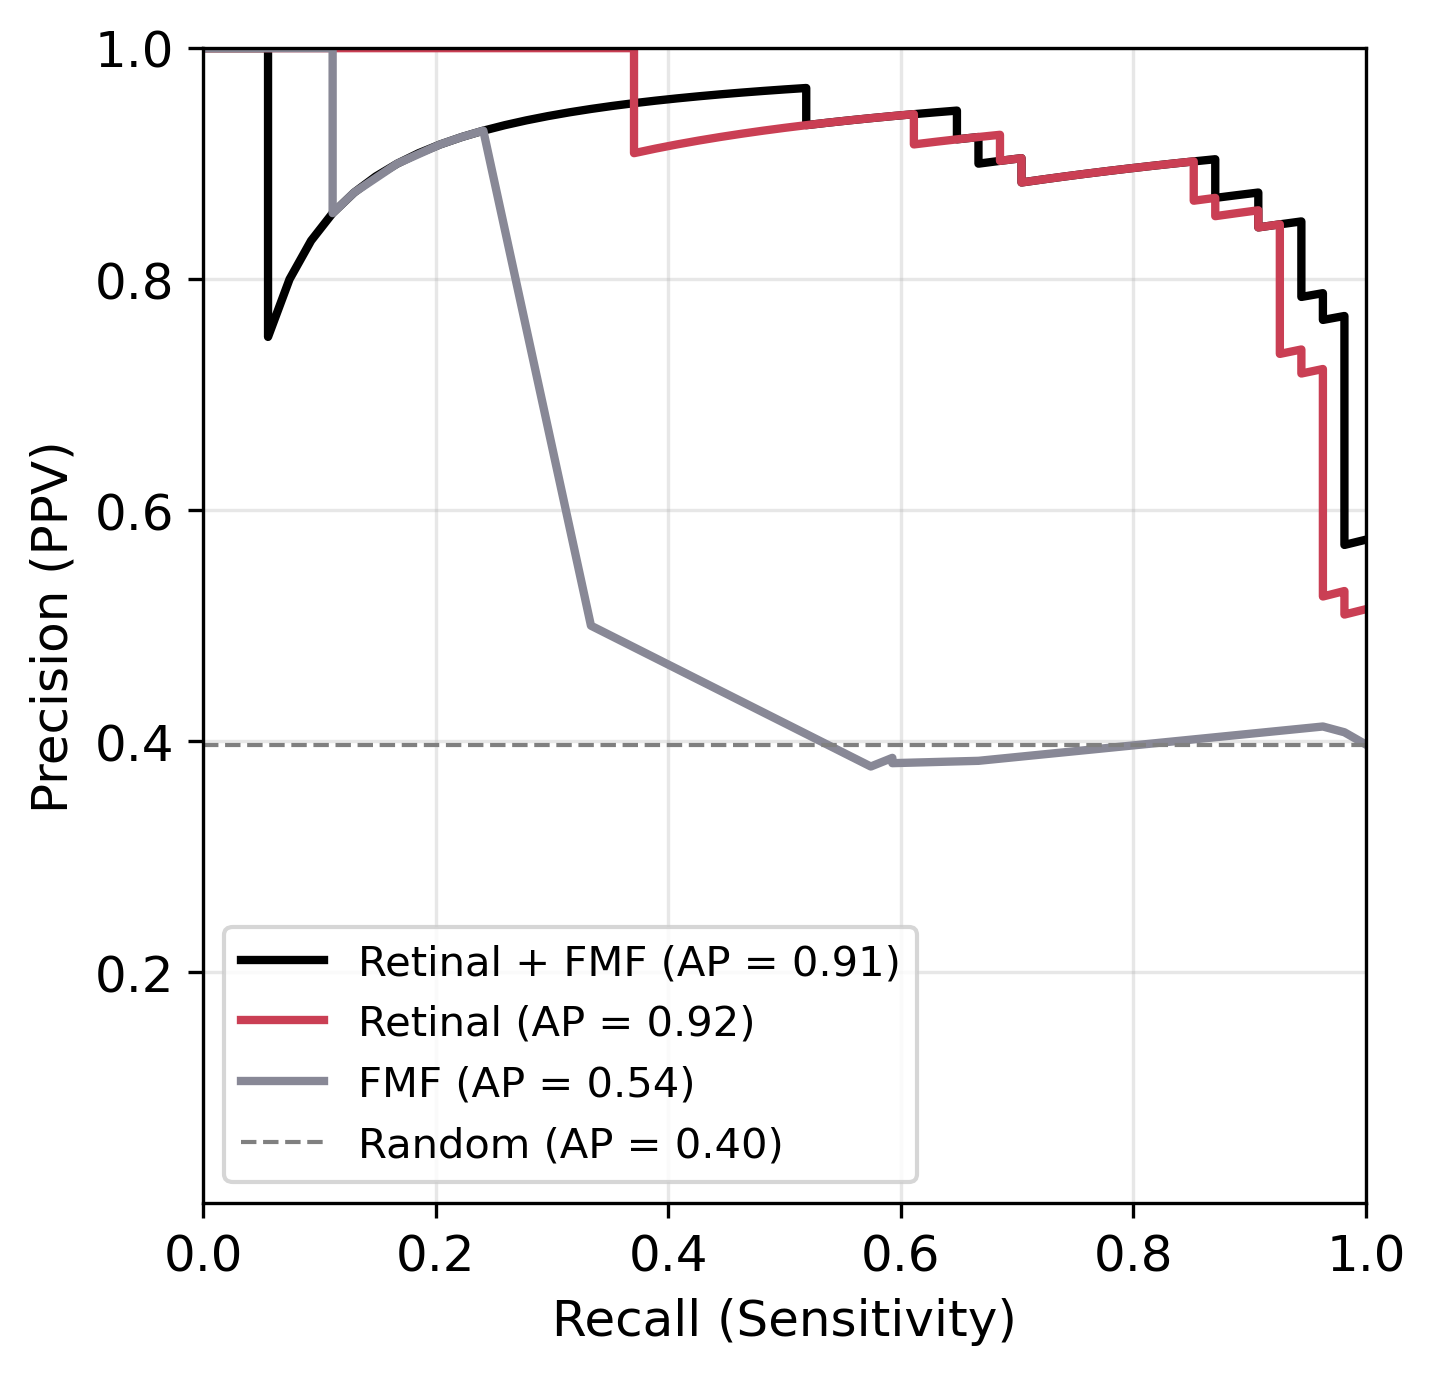

In [16]:
plt.figure(figsize=(fig_size, fig_size), dpi=dpi)

# both
get_test_pr(cu_all_probs["label"], cu_all_probs["pw_1"] + cu_all_probs["fmf_prob"], curve_label="Retinal + FMF", color="black");

# retinal
get_test_pr(cu_all_probs["label"], cu_all_probs["pw_1"], curve_label="Retinal", color="#CA3F54")

#fmf
get_test_pr(cu_all_probs["label"], cu_all_probs["fmf_prob"], curve_label="FMF", color="#888896", rand=True)

plt.savefig('/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/extended_data/fig_1/a_pr.pdf') 

plt.show()

### Extended Data Figure 1B

In [17]:
data_path = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/clinical_data"

In [18]:
sf_cases = f"{data_path}/final_sf_20251028.pkl"
with open(sf_cases, "rb") as f:
    sf_cases = pickle.load(f)
nsf_cases = f"{data_path}/final_nsf_20251028.pkl"
with open(nsf_cases, "rb") as f:
    nsf_cases = pickle.load(f)
eope_cases = f"{data_path}/final_eope_20251017.pkl"
with open(eope_cases, "rb") as f:
    eope_cases = pickle.load(f)
lope_cases = f"{data_path}/final_lope_20251028.pkl"
with open(lope_cases, "rb") as f:
    lope_cases = pickle.load(f)
pec_cases = f"{data_path}/final_pec_20251017.pkl"
with open(pec_cases, "rb") as f:
    pec_cases = pickle.load(f)

In [19]:
pec_data = cu_all_probs[['pw_1', 'label', 'id', "fmf_prob"]].copy()
pec_data.loc[:, "pec"] = [id in pec_cases for id in pec_data["id"]]
pec_data.loc[:, "sf"] = [id in sf_cases for id in pec_data["id"]]
pec_data.loc[:, "nsf"] = [id in nsf_cases for id in pec_data["id"]]
pec_data.loc[:, "eope"] = [id in eope_cases for id in pec_data["id"]]
pec_data.loc[:, "lope"] = [id in lope_cases for id in pec_data["id"]]

In [20]:
cases = ["pec", "sf", "nsf", "eope", "lope"]
pw_results = None
thresh = 0.5
print(thresh)
for c in cases:
    for pw in range(1, 2):
        column = f"pw_{pw}"
        if "pec" == c:
            subset = pec_data[(~pec_data[column].isna())]
        else:
            subset = pec_data[(~pec_data[column].isna()) & ((pec_data[c] & pec_data["pec"]) | ~pec_data["pec"])]
        probabilities = np.array(list(subset[column]))
        predredictions = probabilities > thresh
        grounds = np.array(list(subset["label"]))

        f1 = f1_score(grounds, predredictions)
        tn, fp, fn, tp = confusion_matrix(grounds, predredictions).ravel().tolist()
        tpr = tp / (tp + fn) if (tp + fn) else 0
        fpr = fp / (fp + tn) if (fp + tn) else 0
        tnr = tn / (tn + fp) if (tn + fp) else 0
        ppv = tp / (tp + fp) if (tp + fp) else 0
        npv = tn / (tn + fn) if (tn + fn) else 0
        acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) else 0
        auc_stat = roc_auc_score(grounds, probabilities)
        metric_df = pd.DataFrame({"cases": [c], "AUC": auc_stat, "PPV": ppv, "NPV": npv, "TPR": tpr, "FPR": fpr})
        if pw_results is None:
            pw_results = metric_df
        else:
            pw_results = pd.concat([pw_results, metric_df])
pw_results = pw_results.groupby("cases").mean()
pw_results["order"] = [3, 4, 2, 0, 1]
pw_results = pw_results.sort_values("order")
pw_results

0.5


,AUC,PPV,NPV,TPR,FPR,order
cases,,,,,,
pec,0.943541,0.847458,0.948052,0.925926,0.109756,0
sf,0.930680,0.790698,0.948052,0.894737,0.109756,1
nsf,0.974085,0.640000,1.000000,1.000000,0.109756,2
eope,0.953659,0.678571,0.986486,0.950000,0.109756,3
lope,0.937590,0.775000,0.960526,0.911765,0.109756,4


In [21]:
n_values = [sum(pec_data["pec"]), sum(pec_data["sf"]), sum(pec_data["nsf"]), sum(pec_data["eope"]), sum(pec_data["lope"])]

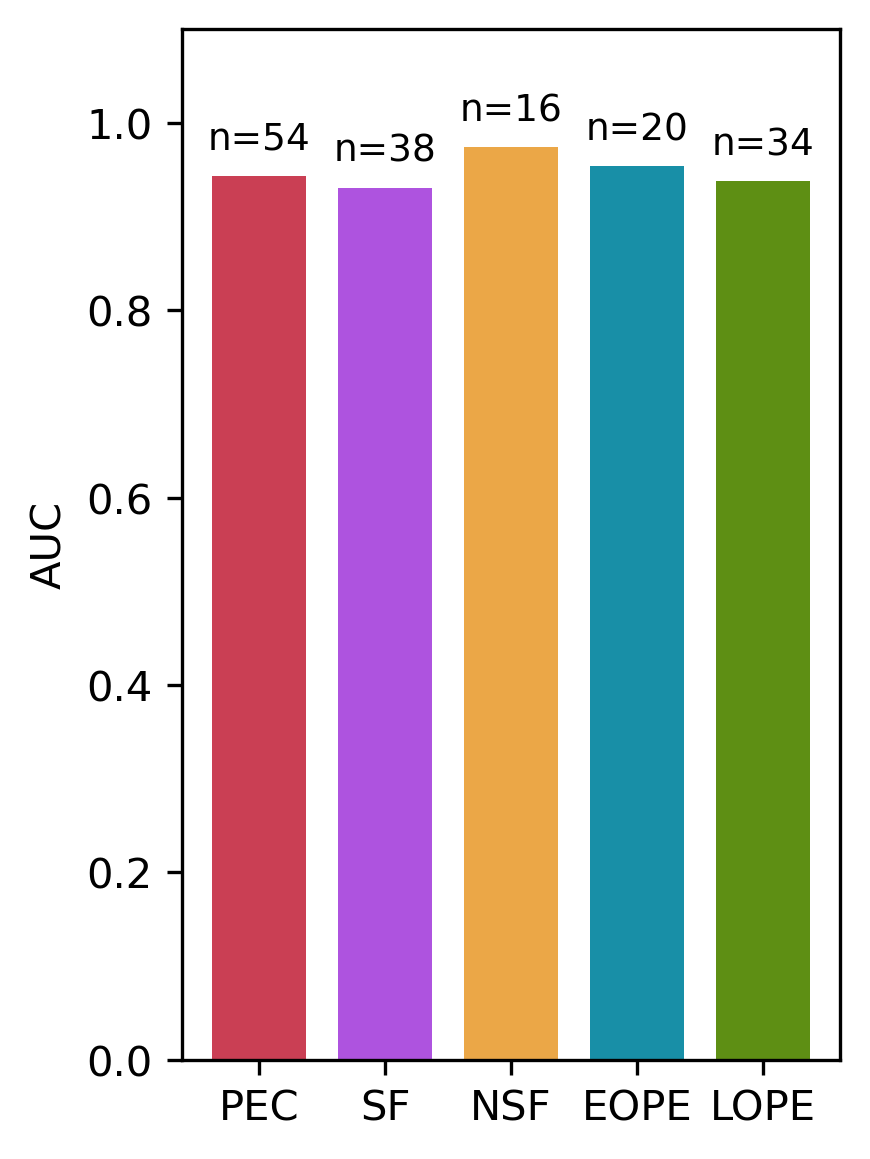

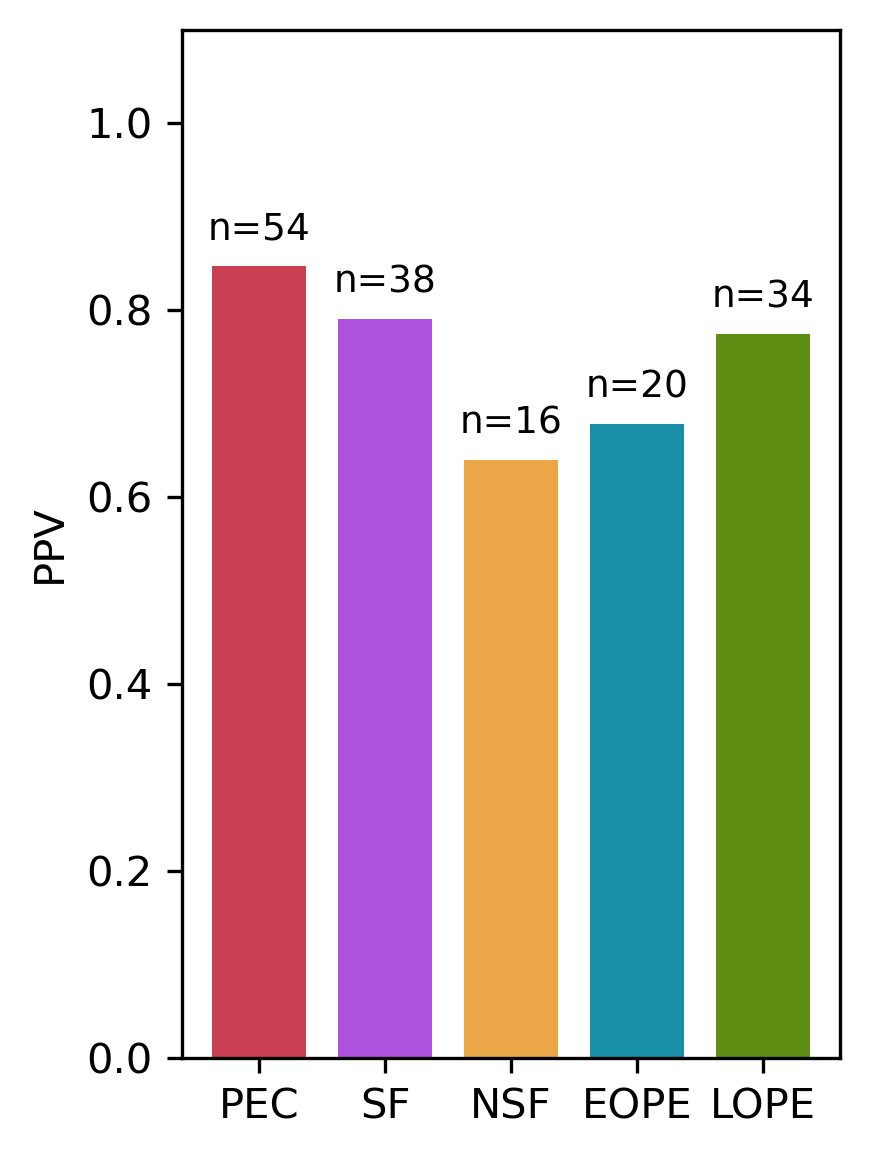

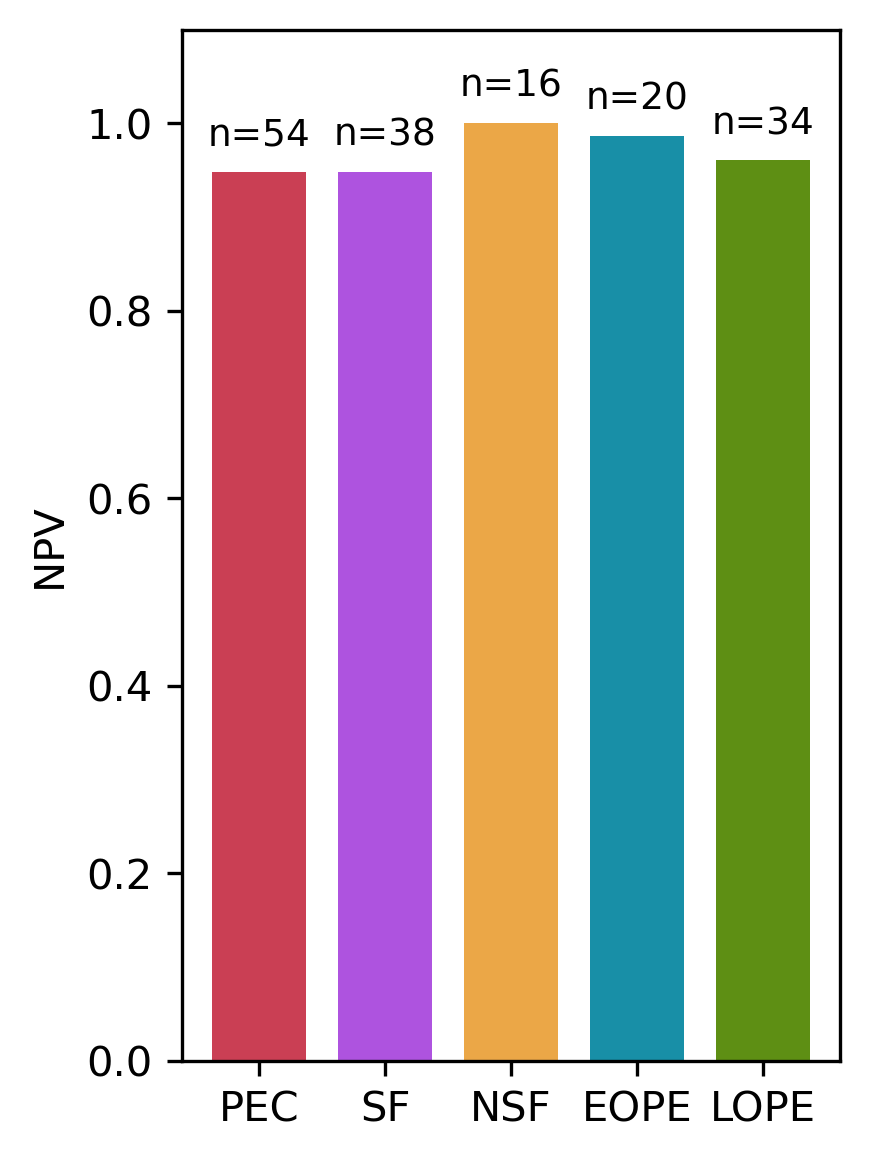

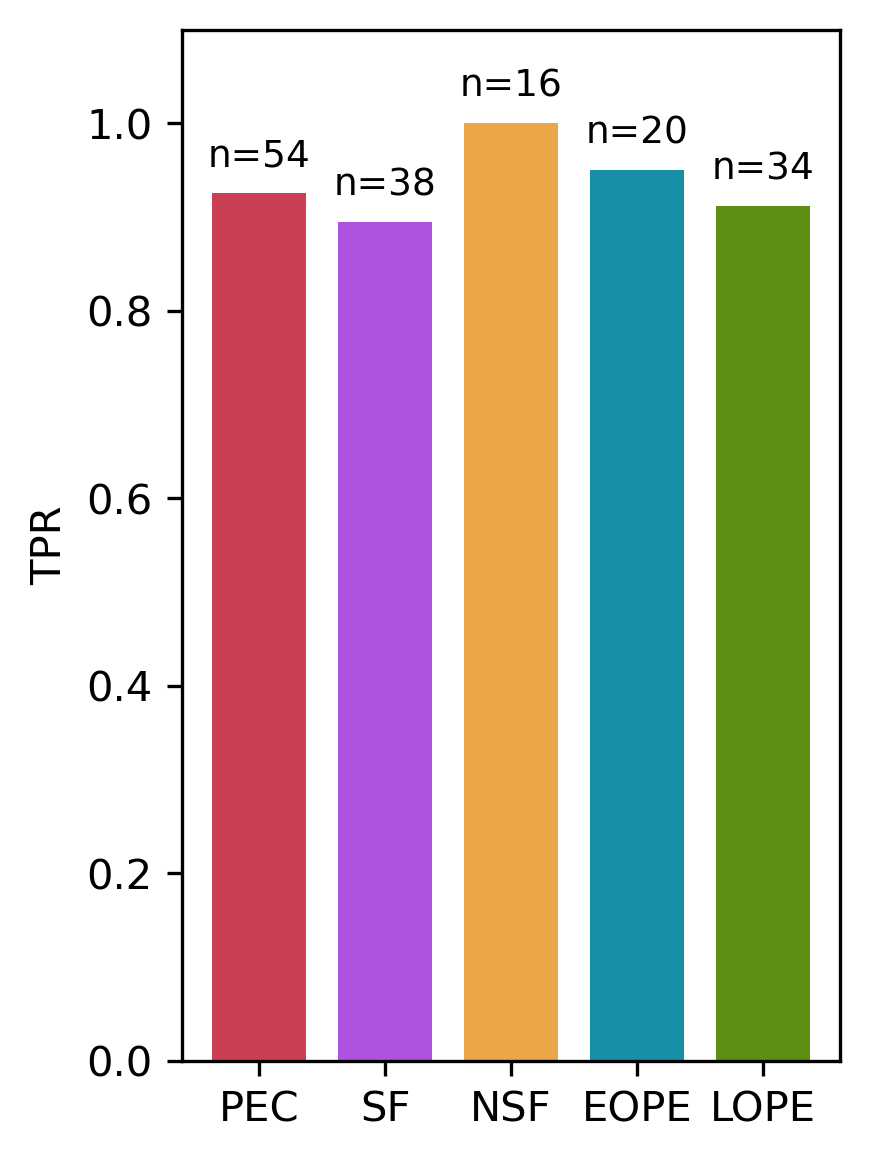

In [22]:
# BAR PLOTS
for col in pw_results.columns:
    if col in ["order", "FPR", "cases"]:
        continue
    plt.figure(figsize=(3, 4), dpi=dpi)
    bars = plt.bar([i.upper() for i in pw_results.index], pw_results[col], width=0.75, color=["#CA3F54", "#AE53DF", "#EBA747", "#188FA7", "#5E8F14"])
    for bar, n_value in zip(bars, n_values):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2.,
            height + 0.02,
            f'n={n_value}',
            ha='center',
            va='bottom',
            fontsize=9
        )
    plt.ylabel(col)
    plt.tight_layout()
    plt.ylim(0,1.1)
    plt.savefig(f'/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/extended_data/fig_1/b_{col.lower()}.pdf') 

    plt.show()

### Extended Data Figure 1C

In [23]:
pec_5_path = "/gpfs/data/shenhavlab/PROJECTS/visionary_ai/data/columbia/final_pec_hc/run_20251017/meta_probs_auc_0.5/XGBoost/{n_estimators_100,max_depth_3,learning_rate_0.3,subsample_1.0,scale_pos_weight_8,n_feats_8}_oof.pkl"

In [24]:
def get_feat_imp(imp_df, save_path, n_pop=10, feats=8):
    """ healthy control feature importance heatmap """
    
    pw_cols = [f"PW{i}" for i in range(1, n_pop + 1)]
    
    heatmap_raw = pd.DataFrame(index=imp_df.index)
    if n_pop == 1:
        if ('imp', n_pop) in imp_df.columns:
            heatmap_raw[f"HC"] = imp_df[('imp', n_pop)].values
        elif n_pop in imp_df.columns:
            heatmap_raw[f"HC"] = imp_df[n_pop].values
        pw_cols = ["HC"]
    else:
        for i in range(1, n_pop + 1):
            if ('imp', i) in imp_df.columns:
                heatmap_raw[f"PW{i}"] = imp_df[('imp', i)].values
            elif i in imp_df.columns:
                heatmap_raw[f"PW{i}"] = imp_df[i].values
    
    heatmap_raw.index = pd.Series(heatmap_raw.index).map(bl_clean).tolist()
    heatmap_raw = heatmap_raw.astype(float)
    
    heatmap_raw = heatmap_raw.fillna(0)
    
    def get_base_feature(feat_name):
        """
        strip trailing model type suffix like LR, RF, XGB to get the base feature name
        """
        match = re.match(r'^(.*?)\s+(LR|RF|XGB)$', feat_name)
        if match:
            return match.group(1), match.group(2)
        return feat_name, ''
    
    base_names = []
    model_types_list = []
    for feat in heatmap_raw.index:
        base, model = get_base_feature(feat)
        base_names.append(base)
        model_types_list.append(model)
    
    heatmap_raw['base_feature'] = base_names
    heatmap_raw['model_type_suffix'] = model_types_list
    
    agg_df = heatmap_raw.groupby('base_feature')[pw_cols].sum()
    
    model_suffixes_per_base = heatmap_raw.groupby('base_feature')['model_type_suffix'].apply(
        lambda x: sorted(set(s for s in x if s != ''))
    )
    
    display_names = {}
    for base in agg_df.index:
        suffixes = model_suffixes_per_base.get(base, [])
        if suffixes:
            display_names[base] = f"{base} ({'/'.join(suffixes)})"
        else:
            display_names[base] = base
    
    agg_df.index = [display_names[base] for base in agg_df.index]

    agg_df[pw_cols] = agg_df[pw_cols].div(agg_df[pw_cols].sum(axis=0), axis=1)
    
    agg_df['prevalence'] = (agg_df[pw_cols] > 0).sum(axis=1)
    agg_df['mean_imp'] = agg_df[pw_cols].mean(axis=1)
    agg_df = agg_df.sort_values(['prevalence', 'mean_imp'], ascending=[False, False])
    agg_df = agg_df.drop(columns=['prevalence', 'mean_imp'])

    agg_df = agg_df.head(feats)
    
    fig, ax = plt.subplots(figsize=(8, max(5, len(agg_df) * 0.4)), dpi=dpi)
    cbar_kws = {'label': 'Meta-Learner Base Learner Importance'}
    
    sns.heatmap(
        agg_df,
        annot=True,
        fmt=".2f",
        cmap="rocket_r",
        linewidths=0.5,
        ax=ax,
        cbar_kws=cbar_kws,
        mask=(agg_df == 0),
        vmin=0,
        annot_kws={"size": 8}
    )
    
    ax.set_ylabel("Feature Set", fontsize=8)
    ax.tick_params(axis='y', labelsize=8, pad=150)
    ax.set_yticklabels(
        wrap_labels(list(agg_df.index), 30), 
        rotation=0, 
        ha='left',
        fontsize=8
    )
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.label.set_size(8)
    cbar.ax.tick_params(labelsize=8)
    
    ax.set_xlabel("Control Group", fontsize=8)
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

In [25]:
all_data = []
pw = 1
for path in [pec_5_path]:
    all_pw_data = pd.DataFrame({"bl": [], "pw": []})
    with open(path, "rb") as f:
        data = pickle.load(f)
        for i in range(len(list(data[6].keys()))):
            test_i = pd.DataFrame({"pw": pw, "bl": data[3][i].values, f"imp_{list(data[6].keys())[i]}": data[6][list(data[6].keys())[i]].feature_importances_})
            all_pw_data = all_pw_data.merge(test_i, on=["bl", "pw"], how="outer")
    pw += 1
    all_pw_data = all_pw_data.fillna(0)
    all_data.append(all_pw_data)
all_data = pd.concat(all_data)
test_data = all_data[["pw", "bl"]]
test_data["imp"] = all_data[list(set(list(all_data.columns)) - set(["pw", "bl"]))].sum(axis=1)
test_pivot = test_data.pivot_table(test_data, index="bl", aggfunc="sum", columns="pw")

/gpfs/data/oermannlab/users/ca3261/.conda/envs/env1/lib/python3.7/site-packages/ipykernel_launcher.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  from ipykernel import kernelapp as app


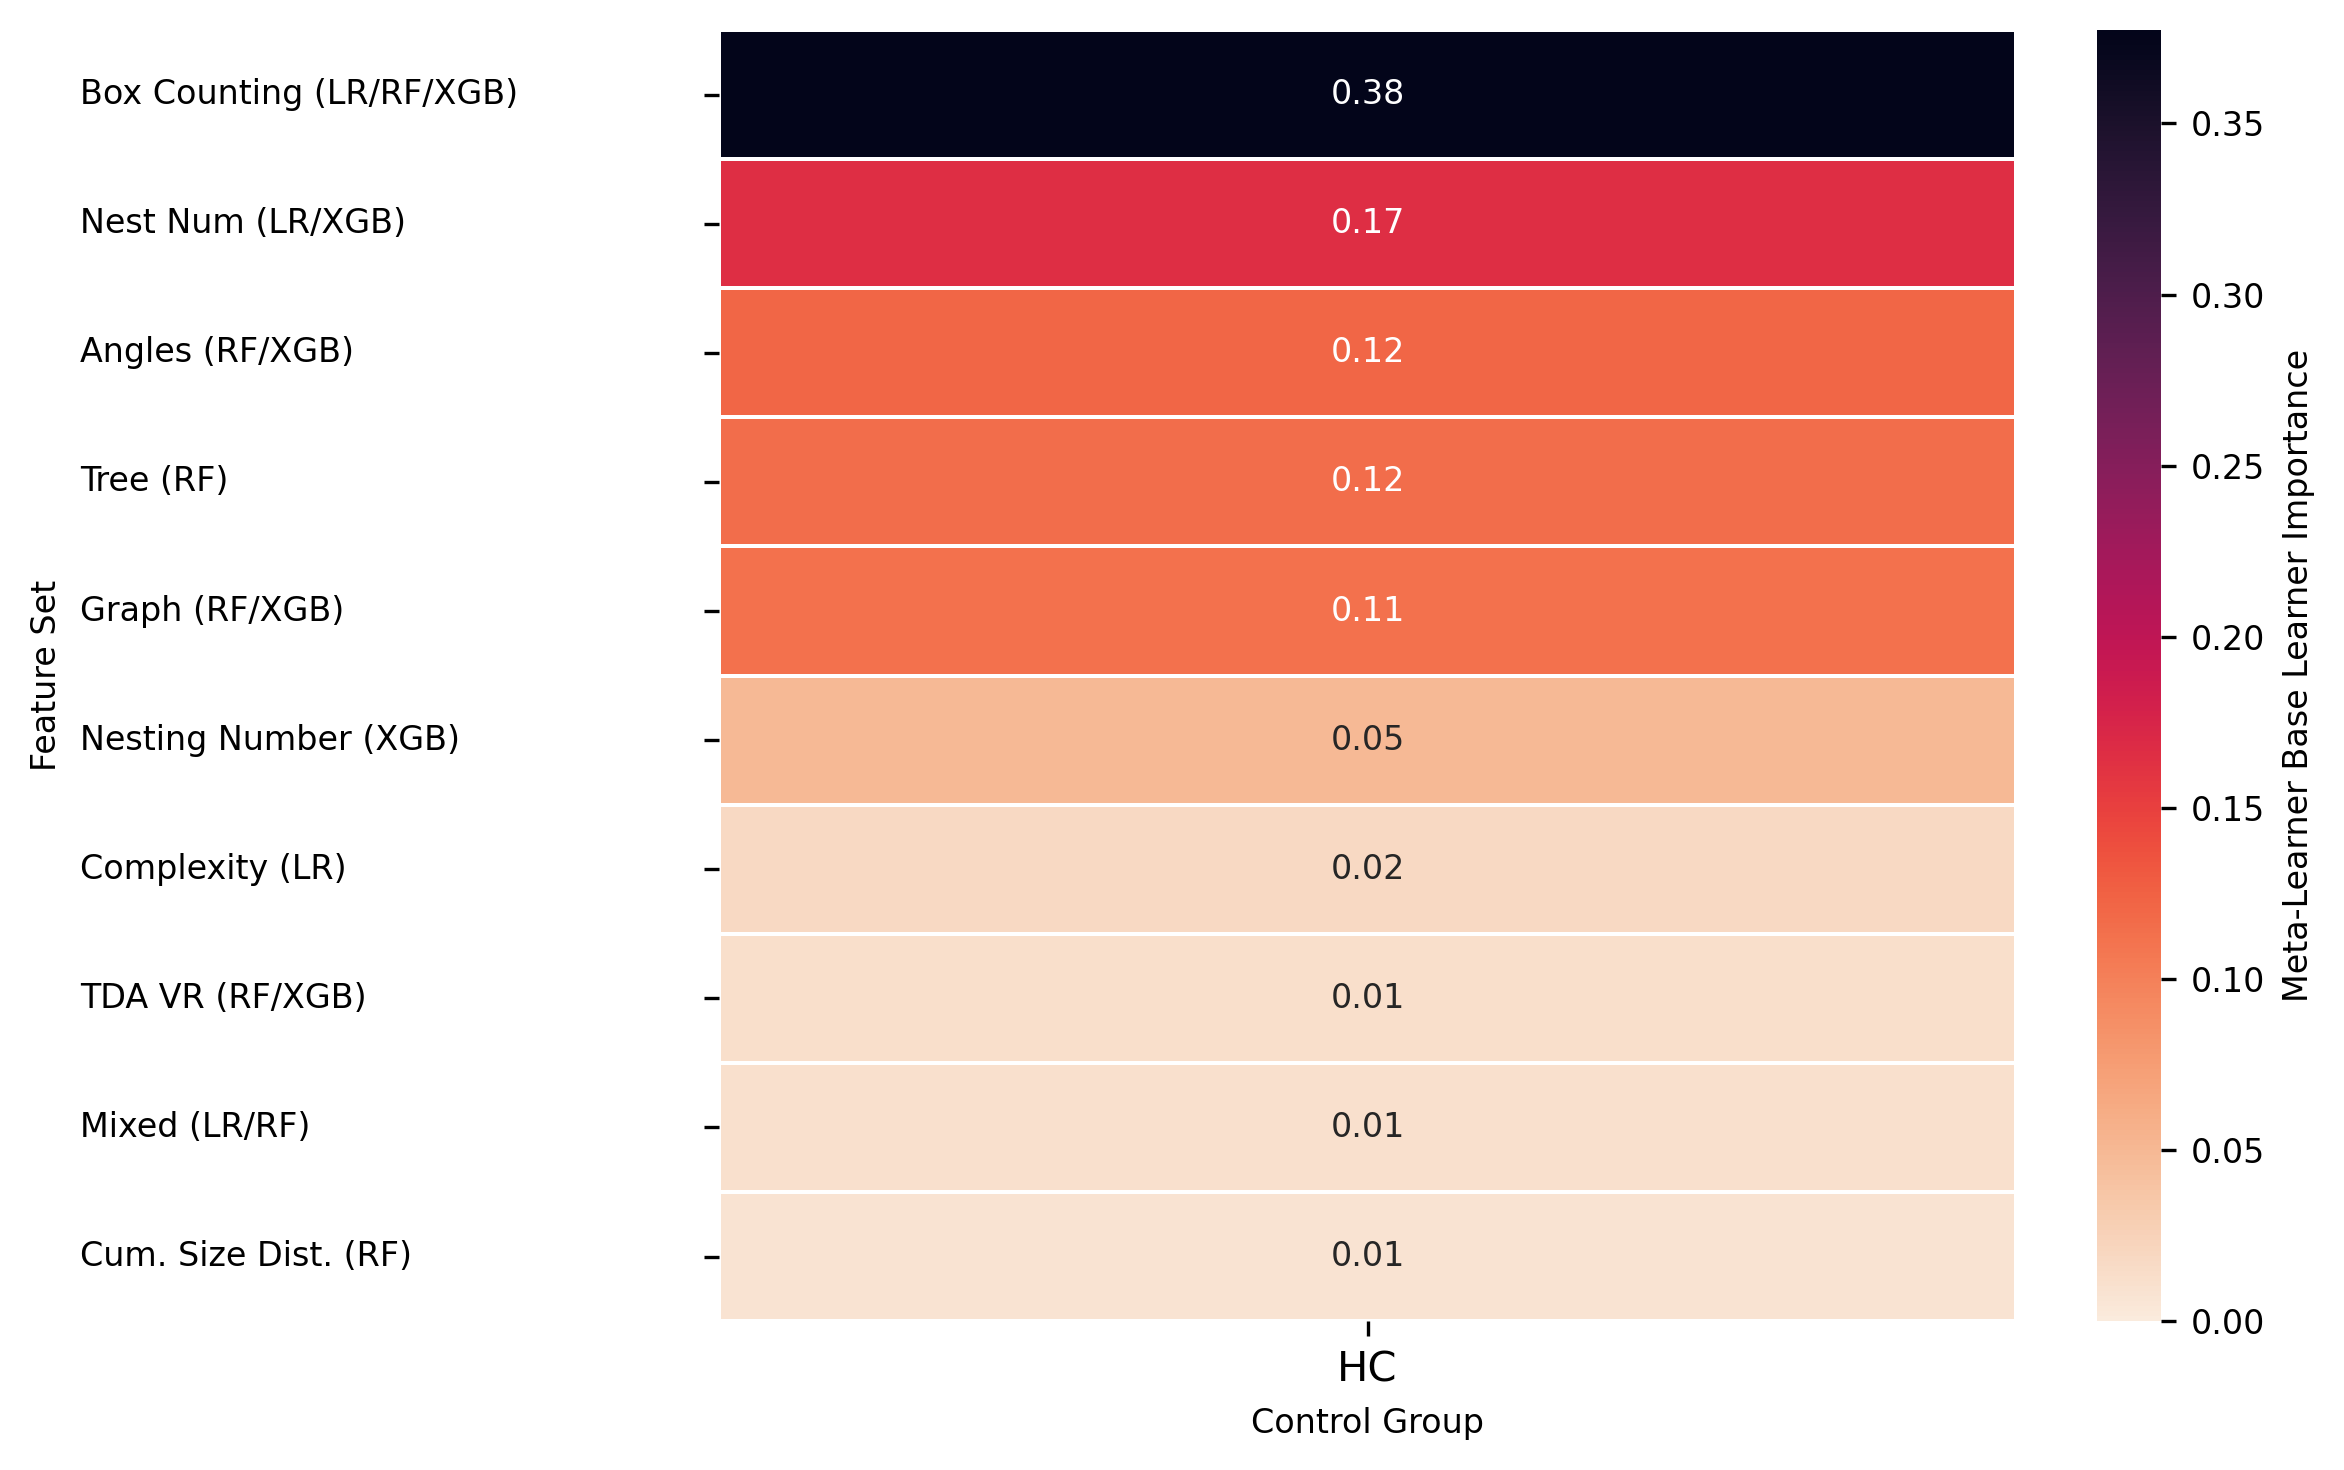

In [26]:
font_size = 12
get_feat_imp(test_pivot, feats=10, save_path="/gpfs/data/shenhavlab/users/ca3261/Visionary_AI/src/analysis/final_figures/final_submission/extended_data/fig_1/c.pdf", n_pop=1)